In [9]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from roar import ALL_VEHICLES, VEHICLE_COLORS

sns.set_style("whitegrid")
sns.set_palette("husl")

In [10]:
df = pl.read_csv("model_comparison_results.csv")
best_models_f1 = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model", "param_feature_selector__feature_set"], keep="first")
    .select(
        [
            "model",
            "param_feature_selector__feature_set",
            "split0_test_weighted_f1",
            "split1_test_weighted_f1",
            "split2_test_weighted_f1",
            "split3_test_weighted_f1",
        ]
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("weighted_f1").alias("metric"),
    )
)

best_models_acc = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model", "param_feature_selector__feature_set"], keep="first")
    .select(
        [
            "model",
            "param_feature_selector__feature_set",
            "split0_test_acc",
            "split1_test_acc",
            "split2_test_acc",
            "split3_test_acc",
        ]
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("accuracy").alias("metric"),
    )
)
# Create a mapping from index to vehicle name
idx2vehicle = {idx: vehicle for idx, vehicle in enumerate(ALL_VEHICLES)}

all_metrics = (
    pl.concat([best_models_f1, best_models_acc])
    .with_columns(pl.col("split").str.extract(r"(\d+)").cast(pl.Int64).alias("split"))
    .with_columns(pl.col("split").replace_strict(idx2vehicle).alias("leave_out_vehicle"))
)

In [11]:
model_name_mapping = {
    "Most Frequent Dummy": "MFD",
    "LogisticRegression_PCA": "PCA+LR",
    "SVM": "SVM",
    "RandomForest": "RF",
    "XGBoost": "XGB",
    "LightGBM": "LGBM",
    "TabPFN": "TabPFN",
}

MODEL_ORDER = [v for v in model_name_mapping.values()]

all_metrics = all_metrics.with_columns(
    pl.col("model").replace_strict(model_name_mapping).alias("model")
)
all_metrics

model,param_feature_selector__feature_set,split,score,metric,leave_out_vehicle
str,str,i64,f64,str,str
"""MFD""","""clean+speed""",0,0.45,"""weighted_f1""","""ID.4"""
"""MFD""","""clean""",0,0.45,"""weighted_f1""","""ID.4"""
"""MFD""","""basic""",0,0.45,"""weighted_f1""","""ID.4"""
"""MFD""","""clean+speed""",1,0.851007,"""weighted_f1""","""Q8 e-tron"""
"""MFD""","""clean""",1,0.851007,"""weighted_f1""","""Q8 e-tron"""
…,…,…,…,…,…
"""MFD""","""clean+speed""",2,0.714286,"""accuracy""","""Taycan"""
"""MFD""","""clean""",2,0.714286,"""accuracy""","""Taycan"""
"""MFD""","""basic""",3,0.666667,"""accuracy""","""E-Golf"""


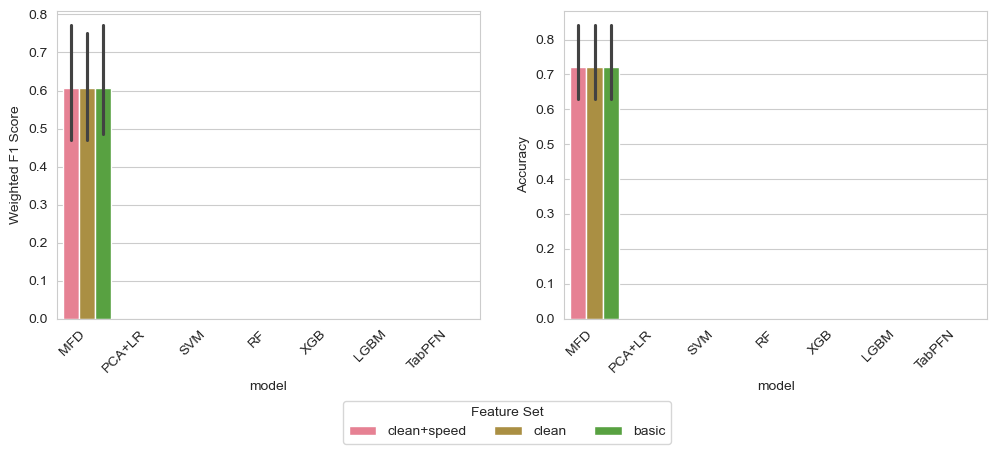

In [12]:
# 1. Mean F1 Score Comparison by Model and Feature Set
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=all_metrics.filter(pl.col("metric") == "weighted_f1").to_pandas(),
    x="model",
    y="score",
    hue="param_feature_selector__feature_set",
    order=MODEL_ORDER,
    ax=ax[0],
)
ax[0].set_ylabel("Weighted F1 Score")

sns.barplot(
    data=all_metrics.filter(pl.col("metric") == "accuracy").to_pandas(),
    x="model",
    y="score",
    hue="param_feature_selector__feature_set",
    order=MODEL_ORDER,
    ax=ax[1],
)
ax[1].set_ylabel("Accuracy")

# Move legend to the middle of the figure
handles, labels = ax[0].get_legend_handles_labels()
# remove individual legends if they exist
if ax[0].get_legend() is not None:
    ax[0].get_legend().remove()
if ax[1].get_legend() is not None:
    ax[1].get_legend().remove()
# place a single legend in the middle of the figure
fig.legend(handles, labels, loc="center", bbox_to_anchor=(0.5, -0.15), title="Feature Set", ncol=3)

# Rotate x-axis labels by 45 degrees
for axis in ax:
    axis.tick_params(axis="x", rotation=45)
    # Optional: align labels to the right for better readability
    for label in axis.get_xticklabels():
        label.set_ha("right")

In [13]:
# Plot the different splits

best_models_f1 = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model"], keep="first")
    .select(
        [
            "model",
            "param_feature_selector__feature_set",
            "split0_test_weighted_f1",
            "split1_test_weighted_f1",
            "split2_test_weighted_f1",
            "split3_test_weighted_f1",
        ]
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("weighted_f1").alias("metric"),
    )
)

best_models_acc = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model"], keep="first")
    .select(
        [
            "model",
            "param_feature_selector__feature_set",
            "split0_test_acc",
            "split1_test_acc",
            "split2_test_acc",
            "split3_test_acc",
        ]
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("accuracy").alias("metric"),
    )
)
# Create a mapping from index to vehicle name
idx2vehicle = {idx: vehicle for idx, vehicle in enumerate(ALL_VEHICLES)}

all_metrics_split = (
    pl.concat([best_models_f1, best_models_acc])
    .with_columns(
        pl.col("split").str.extract(r"(\d+)").cast(pl.Int64).alias("split"),
        pl.col("model").replace_strict(model_name_mapping).alias("model"),
    )
    .with_columns(pl.col("split").replace_strict(idx2vehicle).alias("leave_out_vehicle"))
)

In [14]:
all_metrics_split

model,param_feature_selector__feature_set,split,score,metric,leave_out_vehicle
str,str,i64,f64,str,str
"""MFD""","""basic""",0,0.45,"""weighted_f1""","""ID.4"""
"""MFD""","""basic""",1,0.851007,"""weighted_f1""","""Q8 e-tron"""
"""MFD""","""basic""",2,0.595238,"""weighted_f1""","""Taycan"""
"""MFD""","""basic""",3,0.533333,"""weighted_f1""","""E-Golf"""
"""MFD""","""basic""",0,0.6,"""accuracy""","""ID.4"""
"""MFD""","""basic""",1,0.898876,"""accuracy""","""Q8 e-tron"""
"""MFD""","""basic""",2,0.714286,"""accuracy""","""Taycan"""
"""MFD""","""basic""",3,0.666667,"""accuracy""","""E-Golf"""


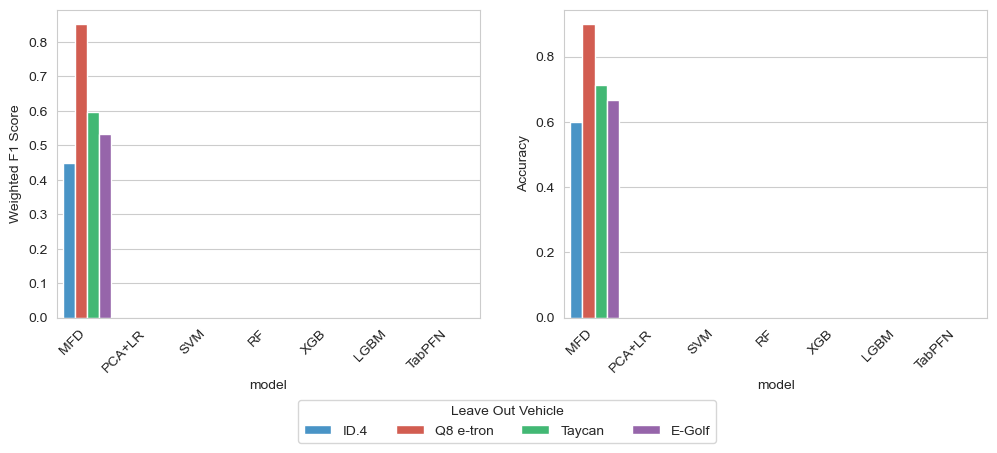

In [15]:
# 1. Mean F1 Score Comparison by Model and Feature Set
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=all_metrics_split.filter(pl.col("metric") == "weighted_f1").to_pandas(),
    x="model",
    y="score",
    hue="leave_out_vehicle",
    order=MODEL_ORDER,
    hue_order=ALL_VEHICLES,
    palette=VEHICLE_COLORS,
    ax=ax[0],
)
ax[0].set_ylabel("Weighted F1 Score")

sns.barplot(
    data=all_metrics_split.filter(pl.col("metric") == "accuracy").to_pandas(),
    x="model",
    y="score",
    hue="leave_out_vehicle",
    order=MODEL_ORDER,
    hue_order=ALL_VEHICLES,
    palette=VEHICLE_COLORS,
    ax=ax[1],
)
ax[1].set_ylabel("Accuracy")

# Move legend to the middle of the figure
handles, labels = ax[0].get_legend_handles_labels()
# remove individual legends if they exist
if ax[0].get_legend() is not None:
    ax[0].get_legend().remove()
if ax[1].get_legend() is not None:
    ax[1].get_legend().remove()
# place a single legend in the middle of the figure
fig.legend(
    handles, labels, loc="center", bbox_to_anchor=(0.5, -0.15), title="Leave Out Vehicle", ncol=4
)

# Rotate x-axis labels by 45 degrees
for axis in ax:
    axis.tick_params(axis="x", rotation=45)
    # Optional: align labels to the right for better readability
    for label in axis.get_xticklabels():
        label.set_ha("right")